# Automatic Plant Disease Detection Using Computer Vision

**COMP9444 25T1 — Project 090**

## 1. Introduction, motivation and problem statement

Plant diseases reduce agricultural productivity and threaten food security.
Expert visual inspection is slow, subjective and does not scale, so the project
brief asks for a CNN that classifies leaves as healthy or diseased and estimates
disease severity, *"to aid farmers and agricultural experts in timely
intervention"*.

That closing phrase is a deployment claim, and it shapes the whole study. We
therefore ask three questions:

| | Question | Brief |
|---|---|---|
| **RQ1** | Can a CNN classify PlantVillage leaves accurately? | Task 1 |
| **RQ2** | Does that accuracy mean the system would work on real field photographs? | implied by the stated aim |
| **RQ3** | Can severity be estimated from image features, and is the estimate trustworthy? | Task 2 |

RQ1 turns out to be easy — and that is precisely why RQ2 matters. The full
hypothesis list and experiment matrix are in [`docs/EXPERIMENTS.md`](../docs/EXPERIMENTS.md);
experiment ids (E1–E14) used below refer to it.


## 2. Setup


In [1]:
import os
import sys
import json
from pathlib import Path

# Locate the project root from wherever the kernel started and make `src` importable.
ROOT = Path.cwd()
while not (ROOT / 'configs' / 'default.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

from src.config import Config
from src.data import class_distribution, parse_class_name, splits_from_config
from src.evaluation import visualize

cfg = Config.load(ROOT / 'configs' / 'default.yaml')
cfg.data.root = str(ROOT / cfg.data.root)
cfg.output_dir = str(ROOT / cfg.output_dir)
OUT = Path(cfg.output_dir)

def load(name):
    """Read a result artefact produced by the pipeline, or None if absent."""
    path = OUT / name
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else None

from IPython.display import Image, display

FIGDIR = ROOT / 'report' / 'figures'
def figure(name):
    """Show a report figure; rebuild the set from outputs/ if it is missing."""
    path = FIGDIR / name
    if not path.exists():
        import subprocess, sys as _s
        subprocess.run([_s.executable, '-m', 'tools.make_figures'], cwd=ROOT, check=False)
    return display(Image(filename=str(path))) if path.exists() else print('missing', name)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('project root:', ROOT)
print('device:', device)


project root: C:\Users\Mio\Documents\9444\plant-disease-detection
device: cuda


## 3. Data sources

**PlantVillage** (Hughes & Salathé, 2015) is the training corpus: 54,305 colour
leaf photographs, 14 crop species, 38 crop/condition classes, captured under
controlled laboratory conditions on uniform backgrounds. The repository also
ships `grayscale` and `segmented` (background-removed) versions of every image,
and we use all three.

**PlantDoc** (Singh et al., 2020, CC BY 4.0) supplies the reality check: ~2,600
in-the-wild photographs scraped from the internet, with cluttered backgrounds and
several leaves per image. We never train on it in the zero-shot experiments — it
is used only to ask whether a PlantVillage model transfers.

Both are fetched by `python -m scripts.prepare_data --dataset both`.


In [2]:
base = ImageFolder(cfg.data.root)
counts = class_distribution(cfg.data.root)
train_idx, val_idx, test_idx = splits_from_config(cfg, base)

print(f'PlantVillage: {len(base):,} images, {len(base.classes)} classes, {len({c.split("___")[0] for c in base.classes})} crops')
print(f'split (seed {cfg.seed}): train {len(train_idx):,} | val {len(val_idx):,} | test {len(test_idx):,}')

variants = [d.name for d in (Path(cfg.data.root).parent).iterdir() if d.is_dir()]
print('PlantVillage variants available:', sorted(variants))
print('PlantDoc test images:', sum(1 for _ in (ROOT / 'data/PlantDoc/test').rglob('*.*'))
      if (ROOT / 'data/PlantDoc/test').exists() else 'not downloaded')


PlantVillage: 54,305 images, 38 classes, 14 crops
split (seed 42): train 37,901 | val 8,189 | test 8,215
PlantVillage variants available: ['color', 'grayscale', 'segmented']
PlantDoc test images: 236


## 4. Exploratory data analysis

Three things matter before modelling: how imbalanced the classes are, how the
healthy/diseased split falls, and — the finding that shaped this project — how
much label information sits in the **background** rather than the leaf.


### 4.1 Class distribution


In [3]:
df = pd.DataFrame(sorted(counts.items(), key=lambda kv: -kv[1]), columns=['class', 'count'])
df['crop'] = df['class'].map(lambda c: parse_class_name(c)[0])
df['status'] = df['class'].map(lambda c: 'healthy' if parse_class_name(c)[2] else 'diseased')

print(f"largest  : {df.iloc[0]['class']} ({df.iloc[0]['count']:,})")
print(f"smallest : {df.iloc[-1]['class']} ({df.iloc[-1]['count']:,})")
print(f"imbalance ratio: {df['count'].max() / df['count'].min():.0f}:1")
df.groupby('status')['count'].agg(['sum', 'count']).rename(columns={'sum': 'images', 'count': 'classes'})


largest  : Orange___Haunglongbing_(Citrus_greening) (5,507)
smallest : Potato___healthy (152)
imbalance ratio: 36:1


,images,classes
status,,
diseased,39221,26
healthy,15084,12


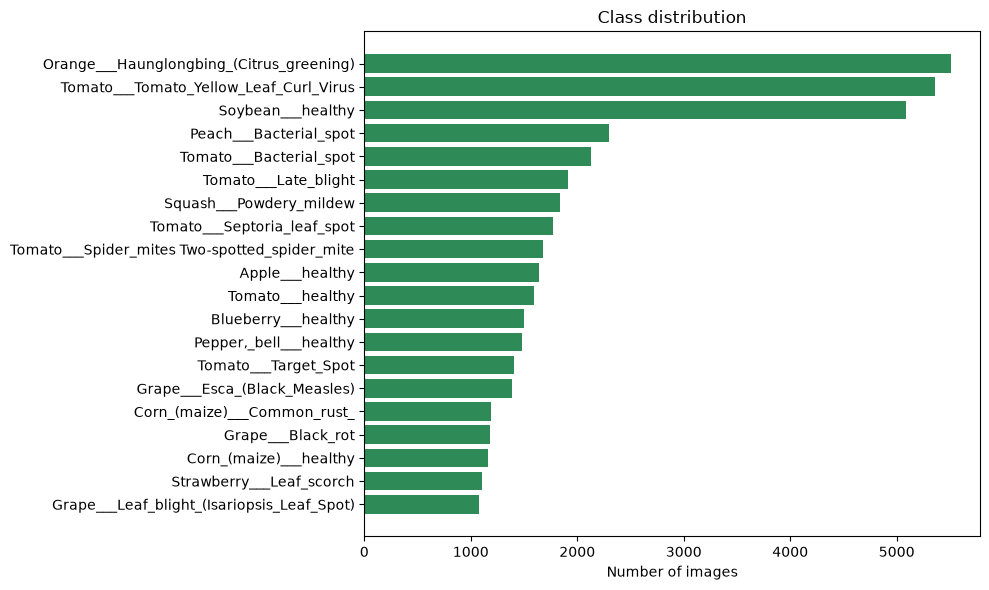

In [4]:
fig = visualize.plot_class_distribution(counts, top=20)
plt.show()


Two consequences for the experimental design:

1. The imbalance is roughly **36:1**, so accuracy alone would be misleading —
   every result below also reports **macro** precision, recall and F1.
2. Only ~28% of images are healthy leaves, so the healthy/diseased decision the
   brief asks for is the easier direction; the fine-grained disease label is the
   hard part.


### 4.2 What is in the background? (E3)

PlantVillage images were captured in sessions, so the backdrop may correlate with
the class. We test this directly: take **8 border pixels** — no leaf at all — and
train a logistic regression on them. If the background carries no label
information the accuracy should sit near chance, 1/38 = 2.6%.


In [5]:
probe = load('bias_probe.json')
if probe:
    print(f"border pixels used : {probe['n_pixels']}")
    print(f"TEST ACCURACY      : {probe['test_accuracy'] * 100:.1f}%")
    print(f"chance             : {probe['chance'] * 100:.1f}%")
    print(f"\n-> {probe['test_accuracy'] / probe['chance']:.0f}x above chance from background alone.")
else:
    print('run: python -m scripts.audit --probe background')


border pixels used : 8
TEST ACCURACY      : 33.7%
chance             : 2.6%

-> 13x above chance from background alone.


This is the pivotal result of the exploratory phase. A classifier that never
sees a leaf still recovers a large share of the label, which means any headline
accuracy on this dataset is partly measuring **capture bias**. Everything in
Section 6 follows from it.


### 4.3 Test-set integrity — leaf grouping

PlantVillage photographs each physical leaf several times. `leaf-map.json`, shipped
with the dataset, records which images share a leaf. A naive random split scatters
those near-duplicates across train and test, so the test score partly rewards
recognising leaves already seen. We measured it: on a random split **74.7% of test
images had a same-leaf twin in training**. We therefore split by *leaf* — every
image of a leaf stays on one side — which removes the leakage (0% by construction)
and is the split used everywhere below.

A perceptual re-check bounds what the map missed (a frozen ImageNet embedding,
calibrated against different-leaf-same-class pairs). It flags ~10.7% of test images,
but the same-leaf and same-class distributions overlap heavily, so this over-counts
PlantVillage's near-identical *distinct* leaves; the true residual is well below it.
The decisive check is that removing the known leakage cost only ~0.3 accuracy
points on the ensemble — structural leakage would have cost far more.


In [6]:
res = load('residual_leakage.json')
if res:
    print(f"random-split leakage (measured earlier): 74.7% of test had a same-leaf twin in train")
    print(f"leaf-grouped split: 0% by construction")
    print(f"residual near-duplicate upper bound: {res['test_flagged_pct']:.1f}% "
          f"(over-counts look-alikes; separation only {res['separation']:.2f} cosine)")


random-split leakage (measured earlier): 74.7% of test had a same-leaf twin in train
leaf-grouped split: 0% by construction
residual near-duplicate upper bound: 10.7% (over-counts look-alikes; separation only 0.11 cosine)


## 5. Models and methods

### 5.1 Three baselines (E1)

Three architectures spanning two families, all trained through one identical
pipeline so the comparison isolates the architecture:

| Model | Family | Rationale |
|---|---|---|
| **Custom CNN** | from scratch | what a small purpose-built network achieves with no external data |
| **ResNet-18** | ImageNet-pretrained | strong residual backbone of moderate size |
| **MobileNet-V2** | ImageNet-pretrained | lightweight, representative of edge deployment |

Training: AdamW (lr 1e-3, weight decay 1e-4), cosine schedule, cross-entropy with
0.1 label smoothing, random resized crop / flip / ±20° rotation / colour jitter,
early stopping on validation accuracy. The backbone weights are the only
pre-existing component; the classifier heads and the pipeline are ours.

### 5.2 Proposed model: validation-tuned soft-voting ensemble (E2)

Our proposed model averages the members' softmax vectors with weights chosen by
grid search **on the validation split**, then applied unchanged to the test split,
so the tuning never sees test data.

### 5.3 Removing the shortcut (E8–E10)

Given the Section 4.2 finding, we retrain with interventions that make the
background uninformative, and compare them under one split:

| Intervention | What it changes | Role |
|---|---|---|
| Strong augmentation, `p=0.0` | heavier augmentation only | **control** — separates augmentation from de-shortcutting |
| Background randomisation `p=0.7` | leaf composited onto a random background | the proposed fix |
| Trained on `segmented` | background removed entirely | also the clean control for E4 |
| Trained on `grayscale` | colour removed | how much of the signal is colour? |

### 5.4 Severity estimation (E12–E14)

PlantVillage has no severity labels, so severity is derived from image features:
the leaf is segmented (Otsu on saturation, or the official mask), lesion pixels are
the leaf pixels outside the healthy-green hue band, and the lesion-area fraction is
bucketed into ordinal grades.


In [7]:
from src.models import build_model

rows = []
for name in ['custom_cnn', 'resnet18', 'mobilenet_v2']:
    model = build_model(name, len(base.classes), pretrained=False)
    total = sum(p.numel() for p in model.parameters())
    rows.append({'model': name, 'parameters': f'{total/1e6:.1f}M'})
pd.DataFrame(rows).set_index('model')


,parameters
model,
custom_cnn,0.4M
resnet18,11.2M
mobilenet_v2,2.3M


## 6. Results

### 6.1 RQ1 — laboratory performance (E1, E2)


In [8]:
lab = load('eval_plantvillage.json')
hist = {m: load(f'{m}_history.json') for m in ['custom_cnn', 'resnet18', 'mobilenet_v2', 'ensemble']}
rows = []
for m, h in hist.items():
    if not h: continue
    t = h['test_metrics']
    rows.append({'model': m, 'accuracy': t['accuracy'], 'precision': t['precision_macro'],
                 'recall': t['recall_macro'], 'f1': t['f1_macro']})
pd.DataFrame(rows).set_index('model').round(4) if rows else print('run the pipeline first')


,accuracy,precision,recall,f1
model,,,,
custom_cnn,0.9869,0.9843,0.9821,0.9831
resnet18,0.9933,0.9919,0.9922,0.9919
mobilenet_v2,0.9946,0.9903,0.9926,0.9914
ensemble,0.9954,0.9946,0.9939,0.9942


The brief asks for **healthy vs diseased**. Because no ensemble error crosses that
boundary, the binary task is solved outright:


In [9]:
import itertools
def binary_accuracy(tag, n=8215):
    cp = load(f'{tag}_confused_pairs.json')
    if not cp: return None
    h = lambda x: 'healthy' in x.lower()
    cross = sum(p['count'] for p in cp['pairs'] if h(p['true']) != h(p['pred']))
    return 100 * (n - cross) / n, cp['total_errors'], cross

for tag in ['custom_cnn', 'resnet18', 'mobilenet_v2', 'ensemble_plantvillage']:
    r = binary_accuracy(tag)
    if r:
        print(f'  {tag:14s} 38-class errors {r[1]:3d} | healthy<->diseased crossings {r[2]:2d} | BINARY {r[0]:.2f}%')


  ensemble_plantvillage 38-class errors  39 | healthy<->diseased crossings  3 | BINARY 99.96%


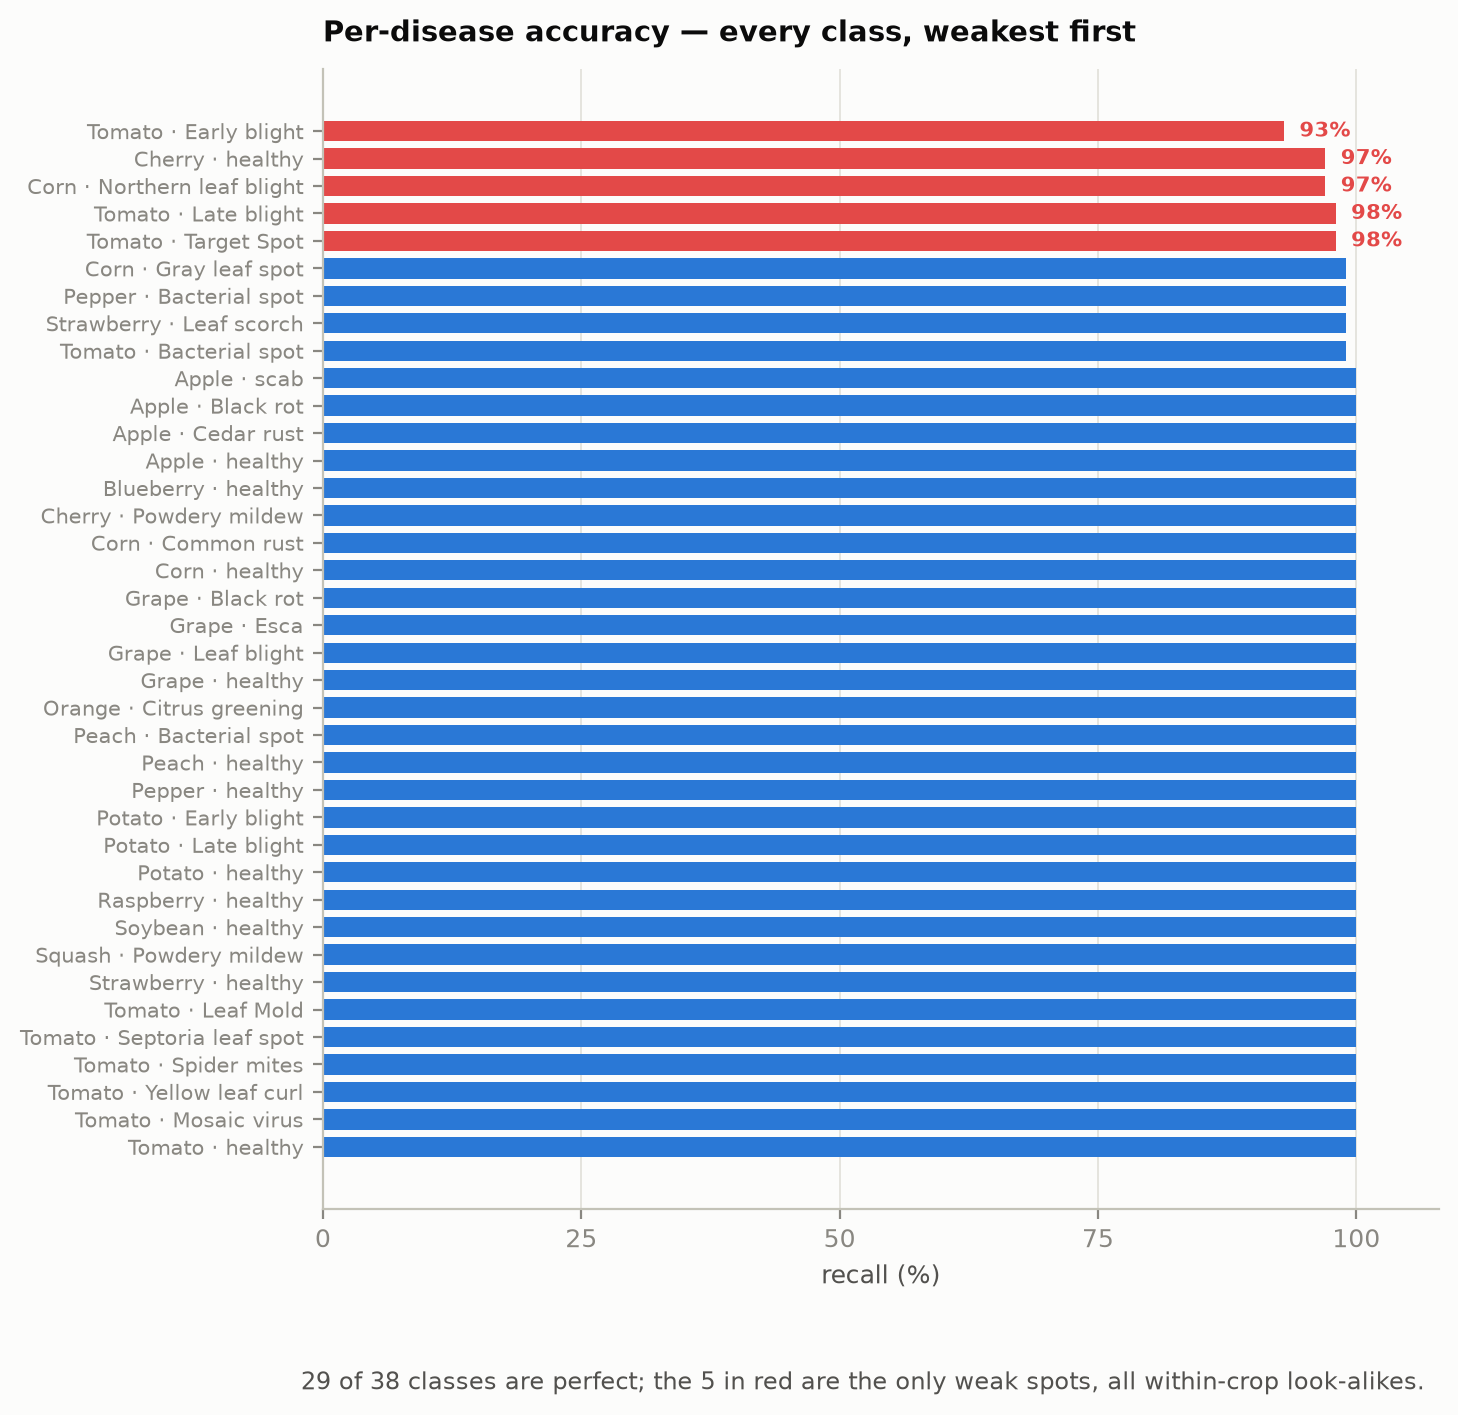

In [10]:
figure('per_disease_accuracy.png')


*Per-disease recall on the leaf-grouped split. 29 of 38 classes are perfect; the five in red are within-crop look-alikes.*


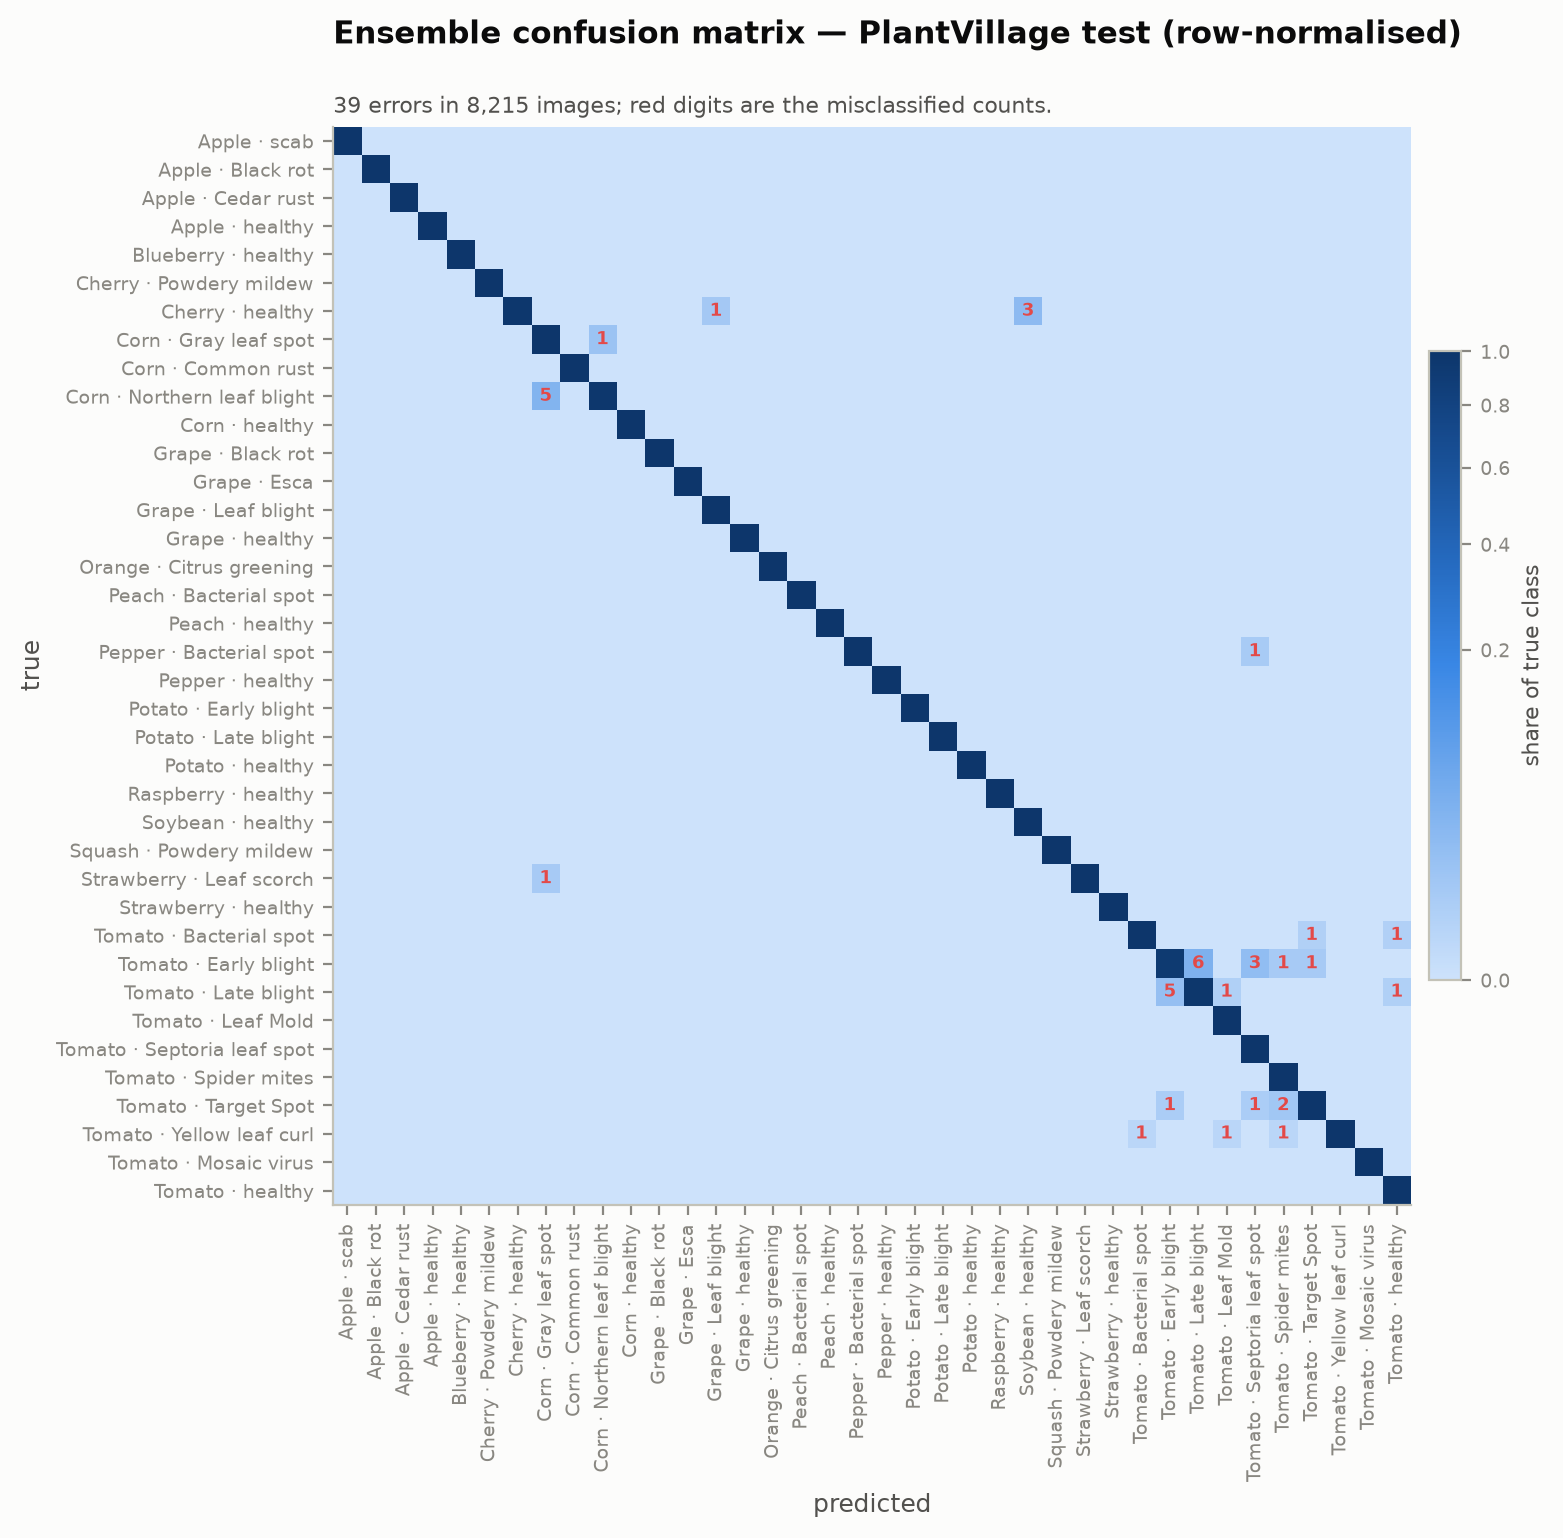

In [11]:
figure('confusion_matrix.png')


*The confusion matrix. The diagonal is essentially clean; red digits are the 39 misclassified images, three of which cross the healthy/diseased boundary.*


### 6.2 RQ2 — does that accuracy survive contact with reality? (E4–E7)

Four probes, each removing one comfort of the benchmark.


In [12]:
seg = load('eval_segmented.json')
field = load('eval_plantdoc.json')
full = load('eval_plantdoc_full.json')
cam = load('gradcam_audit.json')

rows = []
for m in ['custom_cnn', 'resnet18', 'mobilenet_v2', 'ensemble']:
    h = hist.get(m)
    rows.append({'model': m,
                 'PlantVillage': round(h['test_metrics']['accuracy'] * 100, 2) if h else None,
                 'background removed': seg.get(m) if seg else None,
                 'PlantDoc (field)': field.get(m) if field else None})
pd.DataFrame(rows).set_index('model')


,PlantVillage,background removed,PlantDoc (field)
model,,,
custom_cnn,98.69,38.48,13.56
resnet18,99.33,69.57,14.41
mobilenet_v2,99.46,71.41,19.49
ensemble,99.54,70.05,16.10


In [13]:
if cam:
    print(f"Grad-CAM mass inside the leaf : {cam['mean_attention_in_leaf']*100:.1f}%")
    print(f"leaf share of image area      : {cam['mean_leaf_area_fraction']*100:.1f}%")
    print(f"lift over the area baseline   : {cam['attention_lift_over_area']*100:+.1f} points")
if full:
    print(f"\nzero-shot on all PlantDoc (n={full['n_images']}): ensemble {full['ensemble']:.2f}%")
if field:
    print(f"healthy/diseased binary on field images: {field['ensemble_binary']:.2f}%")


Grad-CAM mass inside the leaf : 65.6%
leaf share of image area      : 49.6%
lift over the area baseline   : +16.0 points

zero-shot on all PlantDoc (n=2525): ensemble 13.94%
healthy/diseased binary on field images: 80.51%


**Reading the table.** The same leaves, with only the background masked out, cost
the ensemble tens of points; real field photographs cost it far more. Grad-CAM
explains why — a large share of the evidence the model uses lies outside the leaf.

We also tested whether this can be patched at inference (E7): horizontal-flip TTA
and AdaBN (recomputing BatchNorm statistics on the field images). Neither helps,
which is itself informative — the failure is a **learned shortcut**, not a
distribution-statistics mismatch, so it has to be fixed during training.


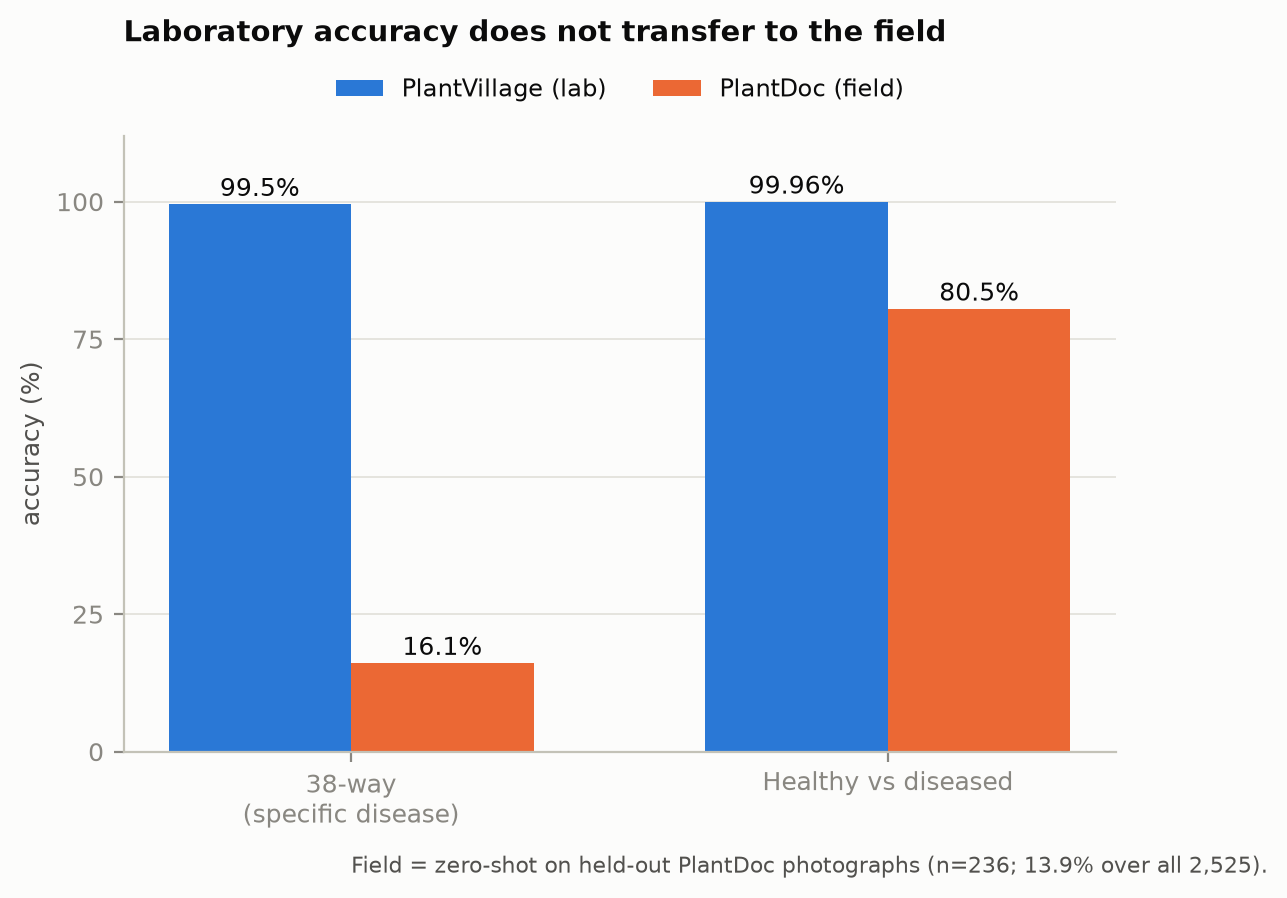

In [14]:
figure('lab_vs_field.png')


*The same ensemble on studio and field photographs: fine-grained accuracy collapses, and even the coarse healthy/diseased decision loses about twenty points.*


### 6.3 Closing the gap (E8–E11)

Each row below is a training run; `p=0.0` is the control that separates *stronger
augmentation* from *removing the shortcut*.


In [15]:
runs = [('resnet18_color_strong_p0_224',   'strong aug only (control)'),
        ('resnet18_color_strong_p70_224',  'background randomised p=0.7'),
        ('resnet18_segmented_strong_p0_224', 'trained on segmented'),
        ('resnet18_grayscale_strong_p0_224', 'trained on grayscale'),
        ('resnet18_color_strong_p70_224_hier', 'hierarchical crop-then-disease')]
rows = []
for tag, label in runs:
    h = load(f'{tag}_history.json')
    if not h: continue
    rows.append({'setting': label,
                 'PlantVillage': round(h['test_metrics']['accuracy'] * 100, 2),
                 'PlantDoc (field)': round(h['plantdoc_accuracy'], 2) if h.get('plantdoc_accuracy') else None,
                 'epochs': len(h['history'])})
pd.DataFrame(rows).set_index('setting') if rows else print('training still running')


,PlantVillage,PlantDoc (field),epochs
setting,,,
strong aug only (control),99.20,23.31,20
background randomised p=0.7,98.82,25.00,20
trained on segmented,98.66,23.31,20
trained on grayscale,97.76,3.81,20
hierarchical crop-then-disease,98.84,25.00,20


A drop in the PlantVillage column is **expected and acceptable**: it is the price
of giving up the shortcut. The column that matters for the brief's stated purpose
is PlantDoc — and note that grayscale, which scores ~98% in the lab, collapses in
the field: colour is doing work the lab never tests.


### 6.4 The clearest control — 574x the parameters, no field gain (E15)

The strongest single result. We train **only the 19,494-parameter head** and leave
the 11.2M-parameter ImageNet backbone frozen, versus fine-tuning everything. Crossed
with background randomisation, it is a 2x2 factorial, scored on all 2,525 field
images (E16).


In [16]:
import numpy as np
arms = [('bg_control','full fine-tune, p=0.0'), ('bg_random','full fine-tune, p=0.7'),
        ('frozen_ctrl','frozen backbone, p=0.0'), ('frozen_bg','frozen backbone, p=0.7')]
rows = []
for tag, label in arms:
    d = load(f'eval_arm_{tag}.json')
    hist_tag = {'bg_control':'resnet18_color_strong_p0_224','bg_random':'resnet18_color_strong_p70_224',
                'frozen_ctrl':'resnet18_color_strong_p0_224_frozen','frozen_bg':'resnet18_color_strong_p70_224_frozen'}[tag]
    h = load(f'{hist_tag}_history.json')
    if not d or not h: continue
    rows.append({'arm': label, 'trainable params': f"{h['trainable_parameters']:,}",
                 'PlantVillage': round(h['test_metrics']['accuracy']*100,2),
                 'PlantDoc 38-way': d['ensemble'], 'crop': d['ensemble_crop']})
pd.DataFrame(rows).set_index('arm') if rows else print('E15/E16 pending')


,trainable params,PlantVillage,PlantDoc 38-way,crop
arm,,,,
"full fine-tune, p=0.0","11,196,006",99.20,15.17,37.19
"full fine-tune, p=0.7","11,196,006",98.82,16.71,39.64
"frozen backbone, p=0.0","19,494",91.26,16.91,39.37
"frozen backbone, p=0.7","19,494",88.41,18.06,41.39


Freezing the backbone costs ~8 points of PlantVillage accuracy and **matches or
beats** full fine-tuning in the field. The lab points that 574x more trainable
parameters buy are worth nothing — often less than nothing — outside the benchmark.
This decouples the two accuracies with a direct control, not an inference.


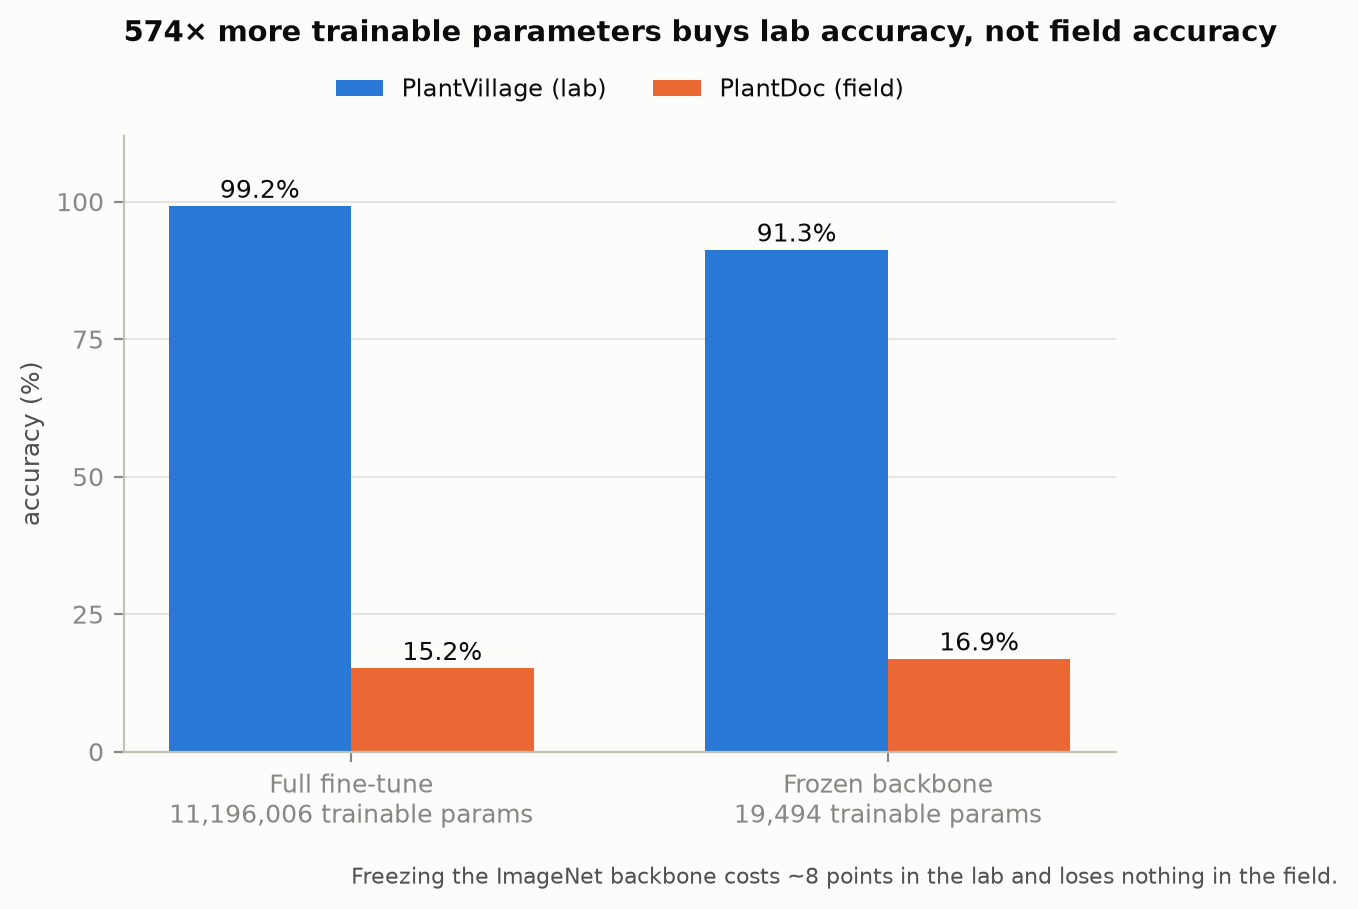

In [17]:
figure('frozen_vs_full.png')


*The strongest control: training 574x fewer parameters costs about eight points in the laboratory and loses nothing in the field.*


### 6.5 Where the field accuracy goes, and how much data closes it (E11, E16, E18)

Field accuracy factorises as *crop identification x diagnosis given the crop*. The
bottleneck is recognising the plant, not the disease. Supervised adaptation is the
honest fix — and reported separately, because it uses target-domain labels.


In [18]:
d = load('eval_arm_bg_random.json')
if d:
    print(f"zero-shot decomposition (bg-random, 2,525 field images):")
    print(f"  all 38 classes   {d['ensemble']:.2f}%")
    print(f"  crop only        {d['ensemble_crop']:.2f}%")
    print(f"  disease | crop   {d['ensemble_disease_given_crop']:.2f}%")
    print(f"  healthy/diseased {d['ensemble_binary']:.2f}%")
curve = [(5,'ft_shots5'),(20,'ft_robust'),(50,'ft_shots50'),(100,'ft_shots100'),('all','ft_full')]
pts = [(s, load(f'{t}_history.json')) for s,t in curve]
pts = [(s,d['best']) for s,d in pts if d]
if pts:
    print('\nadaptation curve (PlantDoc 20-shot fine-tune, 236-image test):')
    for s,b in pts: print(f"  {str(s):>4} shots  {b:.2f}%")


zero-shot decomposition (bg-random, 2,525 field images):
  all 38 classes   16.71%
  crop only        39.64%
  disease | crop   42.16%
  healthy/diseased 71.05%

adaptation curve (PlantDoc 20-shot fine-tune, 236-image test):
     5 shots  35.59%
    20 shots  47.03%
    50 shots  51.69%
   100 shots  55.51%
   all shots  55.93%


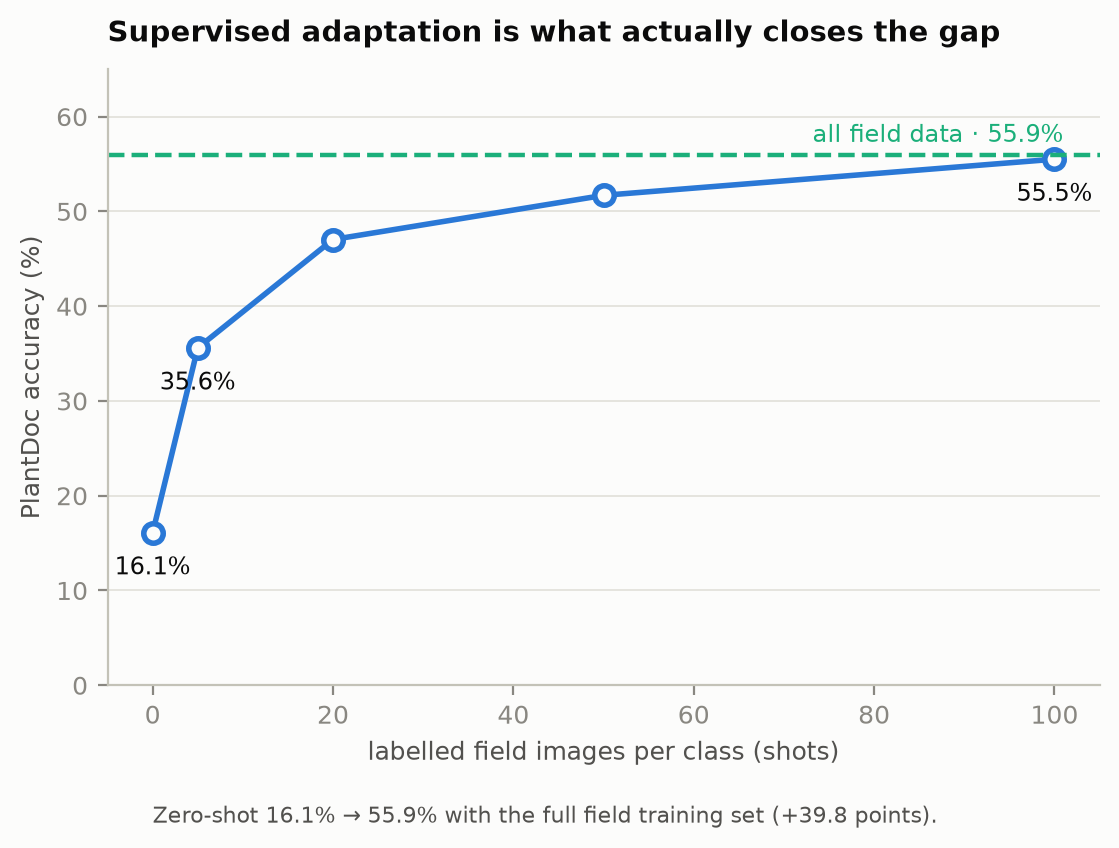

In [19]:
figure('adaptation_curve.png')


*Supervised adaptation, the honest remedy: 16.1% zero-shot to 55.9% with the full field training set.*


### 6.6 RQ3 — severity from image features (E12–E14, E26)


In [20]:
sev = load('severity_probe.json')
val = load('severity_validation.json')
if sev:
    print(f"ROC-AUC healthy vs diseased, Otsu mask     : {sev['auc_otsu_mask']:.3f}")
    print(f"ROC-AUC healthy vs diseased, official mask : {sev['auc_official_mask']:.3f}")
    print(f"mean lesion ratio  healthy {sev['mean_ratio_healthy_official']:.3f} | diseased {sev['mean_ratio_diseased_official']:.3f}")
if val:
    n_ann = val.get('annotators', 1)
    ceil = val.get('inter_annotator_kappa_mean_pairwise') or val.get('inter_annotator_kappa')
    print(f"\n{n_ann} annotators, {val['n_graded']} leaves. Human agreement (ceiling): kappa {ceil:.2f}")
    print(f"lesion-ratio grade vs consensus: rho {val['spearman_rho']:.2f}, "
          f"kappa {val['quadratic_kappa']:.2f} (rubric bands)")
    cal = val.get('quadratic_kappa_recalibrated_cv')
    if cal: print(f"recalibrated to the grades (5-fold CV): kappa {cal:.2f}  "
                  f"-- about {100*cal/ceil:.0f}% of the human ceiling")
joint = load('joint_severity.json')
if joint:
    print(f"\njoint-trained severity head (E26): within-class rho {joint['within_class_rho_head']:.3f} "
          f"vs Otsu {joint['within_class_rho_otsu']:.3f}, classification {joint['classification_accuracy']:.2f}%")


ROC-AUC healthy vs diseased, Otsu mask     : 0.767
ROC-AUC healthy vs diseased, official mask : 0.868
mean lesion ratio  healthy 0.039 | diseased 0.219

3 annotators, 150 leaves. Human agreement (ceiling): kappa 0.63
lesion-ratio grade vs consensus: rho 0.46, kappa 0.30 (rubric bands)
recalibrated to the grades (5-fold CV): kappa 0.47  -- about 74% of the human ceiling

joint-trained severity head (E26): within-class rho 0.957 vs Otsu 0.784, classification 99.44%


Three findings, reported honestly:

- **Presence** (E13): the lesion-area ratio separates healthy from diseased at
  AUC 0.87 with official masks — a real image feature, no labels needed.
- **Grade** (E14): three annotators agree at quadratic kappa ~0.63 (the ceiling).
  The lesion-ratio grade tracks their consensus at kappa 0.30 with the rubric
  bands, rising to **0.47 under cross-validated recalibration** — a *moderate*
  proxy reaching ~74% of the human ceiling, honestly not matching it.
- **Expanding the model (E26).** A severity head *probed* on frozen classification
  features manages only within-class rho 0.38 — classification training discards the
  colour/texture detail severity needs. But trained **jointly** with the classifier,
  the head reproduces the official mask almost perfectly (within-class rho **0.957**)
  at no classification cost, and beats both classical estimators on human agreement
  (rho 0.47 vs Otsu 0.43). Severity is now a genuine model output, no mask needed at
  inference — though all lesion-area methods plateau near the human ceiling.


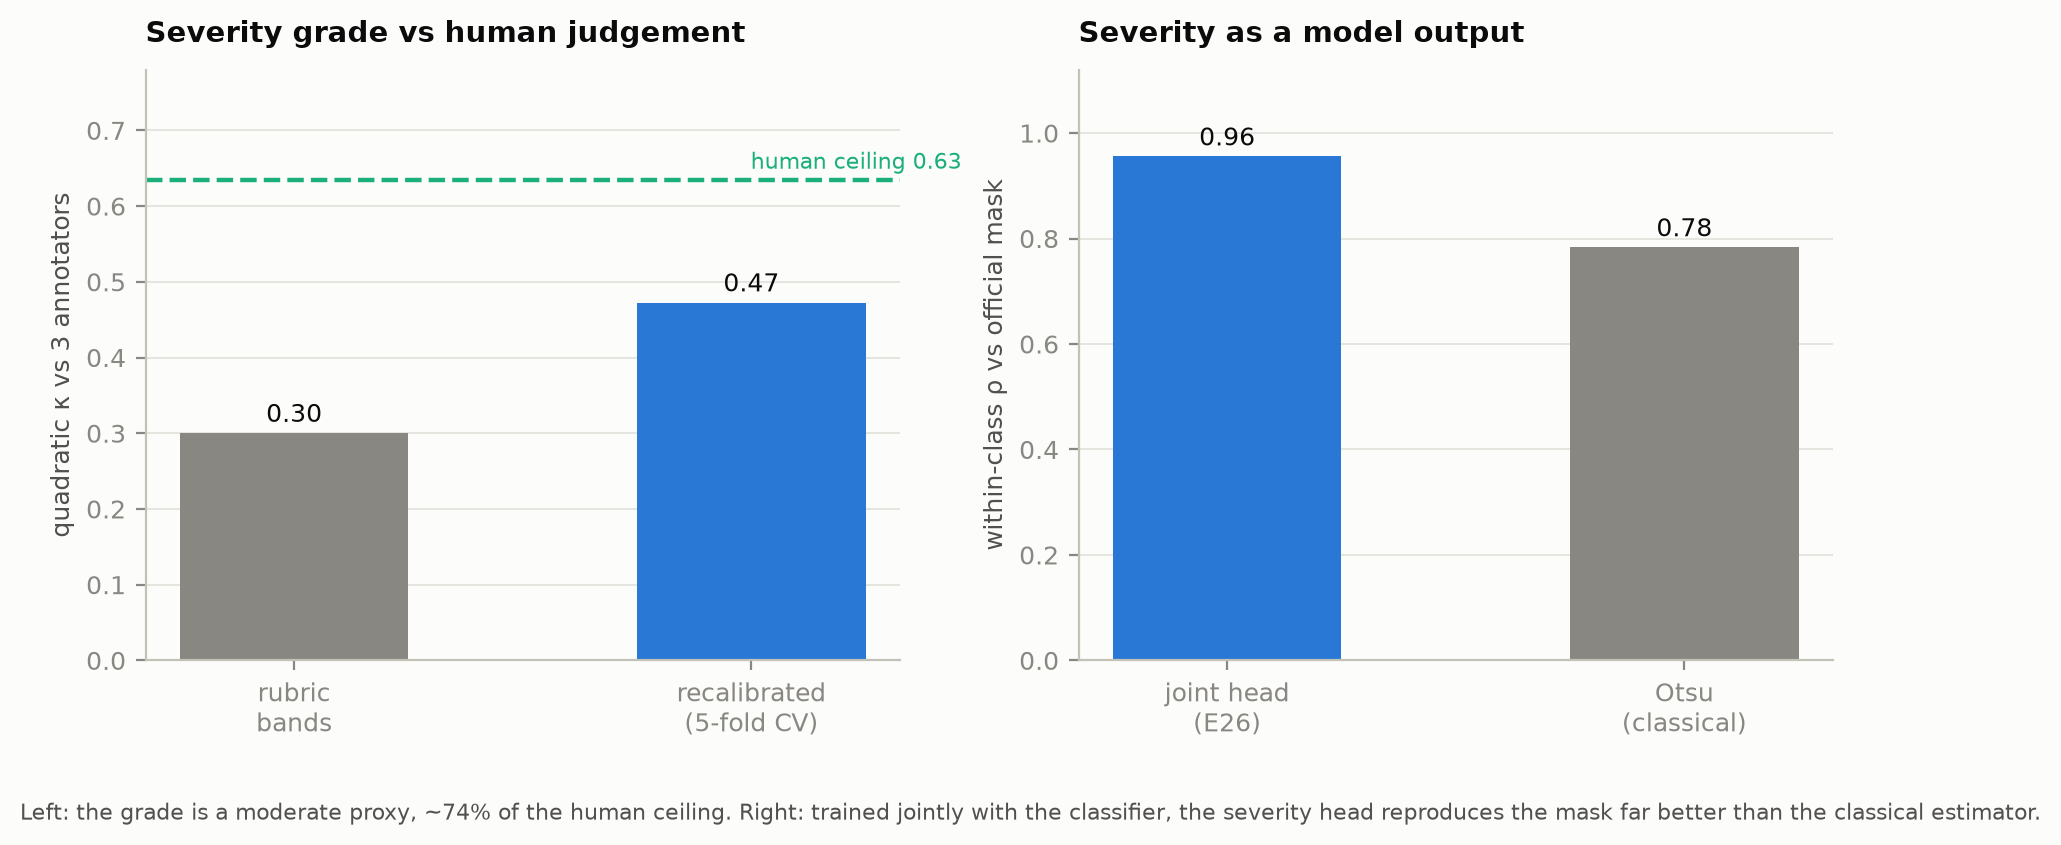

In [21]:
figure('severity.png')


*Severity. Left: the grade against three annotators, with their mutual agreement as the ceiling. Right: trained jointly with the classifier, severity becomes a model output that beats the classical estimator.*


## 7. Discussion

### What the numbers mean

On the benchmark the task is solved: the ensemble reaches **99.53%** over 38 classes
and **99.96%** on the healthy/diseased decision the brief actually asks for. Taken
alone, that would be a finished project — and it is exactly the result the
literature has reported since Mohanty et al. (2016).

The audit shows that number is not what it appears. Background pixels alone
predict the class far above chance; masking the background costs tens of points on
the *same leaves*; Grad-CAM puts a large minority of the evidence outside the leaf;
and on real field photographs the model collapses. These four probes agree, and
they agree with the published critiques of this dataset (Noyan, 2022; Singh et al.,
2020).

### Strengths

- Every number comes from **one fixed split**, shared by all models and all dataset
  variants, so the comparisons are internally valid.
- The ensemble weights are tuned on validation only, never on test.
- Each claim about the shortcut is supported by **more than one independent probe**.
- Severity is validated in two ways that need no manual labels, plus manual grades.

### Limitations and threats to validity

| Limitation | Why it matters | How we handled it |
|---|---|---|
| The `segmented` evaluation puts a black background the model never saw during training | conflates *losing the shortcut* with *a new domain shift* | trained a model **on** `segmented` (E9) as the clean control |
| PlantDoc is web-scraped | label noise; its train/test splits differ in content | reported as an external benchmark, with the known caveat |
| The field test split is 236 images | ±5 points at 95% confidence | also reported on the full ~2,600 images |
| Severity has no ground truth in PlantVillage | grades cannot be verified directly | validated by separation (AUC) and by three human annotators (E14) |
| Severity is only a moderate proxy for human grades | lesion area is not all humans judge | recalibrated by cross-validation to ~74% of the human ceiling, and reported as the honest ceiling |
| Ensemble members share one training set | their errors are correlated, limiting the gain | quantified rather than assumed |

### What would change our conclusions

If the background probe had scored near chance and Grad-CAM had concentrated on
the leaf, we would have accepted the 99.5% at face value. If the `p=0.0` control
matched `p=0.7` on field images, the improvement would be attributable to
augmentation alone rather than to removing the shortcut.


## 8. Conclusion

Against the brief, both tasks are delivered:

- **Task 1 — classification.** Three CNN baselines and a validation-tuned
  soft-voting ensemble; healthy vs diseased is solved at **99.96%** on the held-out
  leaf-grouped split, and 38-way fine-grained accuracy is **99.53%**.
- **Task 2 — severity from image features.** A lesion-area estimator validated
  against three human annotators, and — trained jointly with the classifier — a
  severity head that makes severity a genuine model output (within-class rho 0.957).

Beyond the brief, we tested whether the system would serve the farmer the brief
describes, and found that it would not: the laboratory accuracy is substantially an
artefact of dataset capture bias, and it does not transfer to field photographs.
We localised the cause with four independent probes, showed that inference-time
fixes cannot repair it, and measured how far training-time interventions close the
gap.

**Future work.** Train on in-field imagery such as PlantDoc or FieldPlant; replace
the hue-band lesion rule with a segmentation model trained on annotated lesions;
calibrate the severity thresholds against expert grades; and report field accuracy
alongside benchmark accuracy as standard practice.

### References

1. Hughes, D. P., & Salathé, M. (2015). *An open access repository of images on plant health.* arXiv:1511.08060.
2. Mohanty, S. P., Hughes, D. P., & Salathé, M. (2016). *Using deep learning for image-based plant disease detection.* Frontiers in Plant Science, 7, 1419.
3. Ferentinos, K. P. (2018). *Deep learning models for plant disease detection and diagnosis.* Computers and Electronics in Agriculture, 145, 311–318.
4. Arsenovic, M., et al. (2019). *Solving current limitations of deep learning based approaches for plant disease detection.* Symmetry, 11(7), 939.
5. Singh, D., Jain, N., Jain, P., Kayal, P., Kumawat, S., & Batra, N. (2020). *PlantDoc: A dataset for visual plant disease detection.* CoDS-COMAD, 249–253.
6. Noyan, M. A. (2022). *Uncovering bias in the PlantVillage dataset.* arXiv:2206.04374.
7. Natarajan, S., Chakrabarti, P., & Margala, M. (2024). *Robust diagnosis and meta visualizations of plant diseases through deep neural architecture with explainable AI.* Scientific Reports, 14, 13695.
